In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

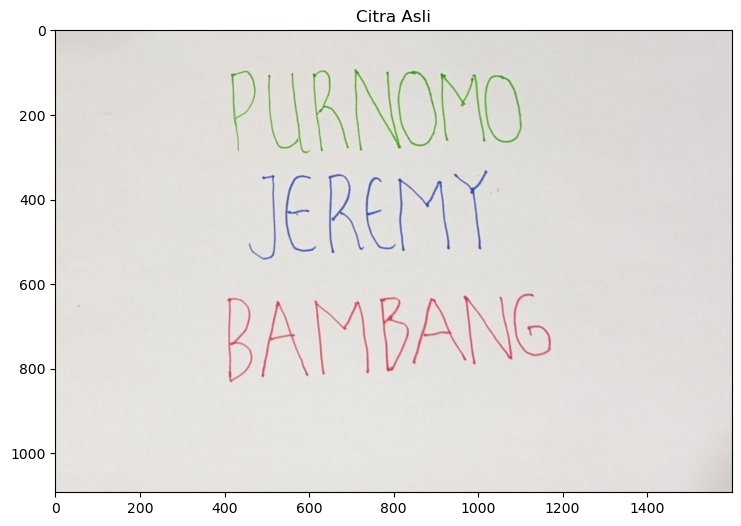

True

In [3]:
# 202431026_Purnomo Jeremy Bambang
# 1. BAGIAN A.1
# Import Library dan Membaca Citra

# Membaca citra
citra_bgr = cv2.imread('Nama_Lengkap.jpeg')

# Konversi BGR ke RGB agar warna sesuai saat ditampilkan di matplotlib
citra_rgb = cv2.cvtColor(citra_bgr, cv2.COLOR_BGR2RGB)

# Menampilkan citra asli
plt.figure(figsize=(10, 6))
plt.imshow(citra_rgb)
plt.title('Citra Asli')
plt.axis('on')
plt.show()

# Menyimpan hasil citra asli
cv2.imwrite('1. A.1. Citra_Asli.jpeg', cv2.cvtColor(citra_rgb, cv2.COLOR_RGB2BGR))

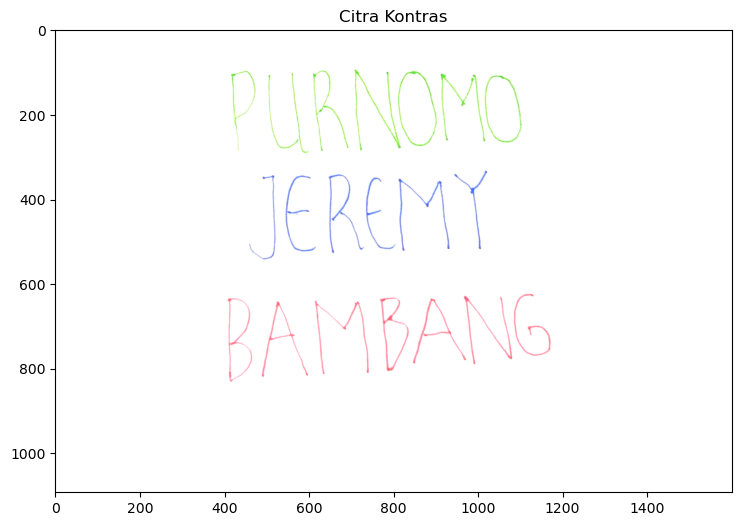

True

In [4]:
# 202431026_Purnomo Jeremy Bambang
# 1. Membuat Citra Kontras

alpha = 1.5   # kontras
beta = 0      # kecerahan

citra_kontras = cv2.convertScaleAbs(citra_rgb, alpha=alpha, beta=beta)

plt.figure(figsize=(10, 6))
plt.imshow(citra_kontras)
plt.title('Citra Kontras')
plt.axis('on')
plt.show()

# Menyimpan hasil citra kontras
cv2.imwrite('1. A.2. Citra_Kontras.jpeg', cv2.cvtColor(citra_kontras, cv2.COLOR_RGB2BGR))

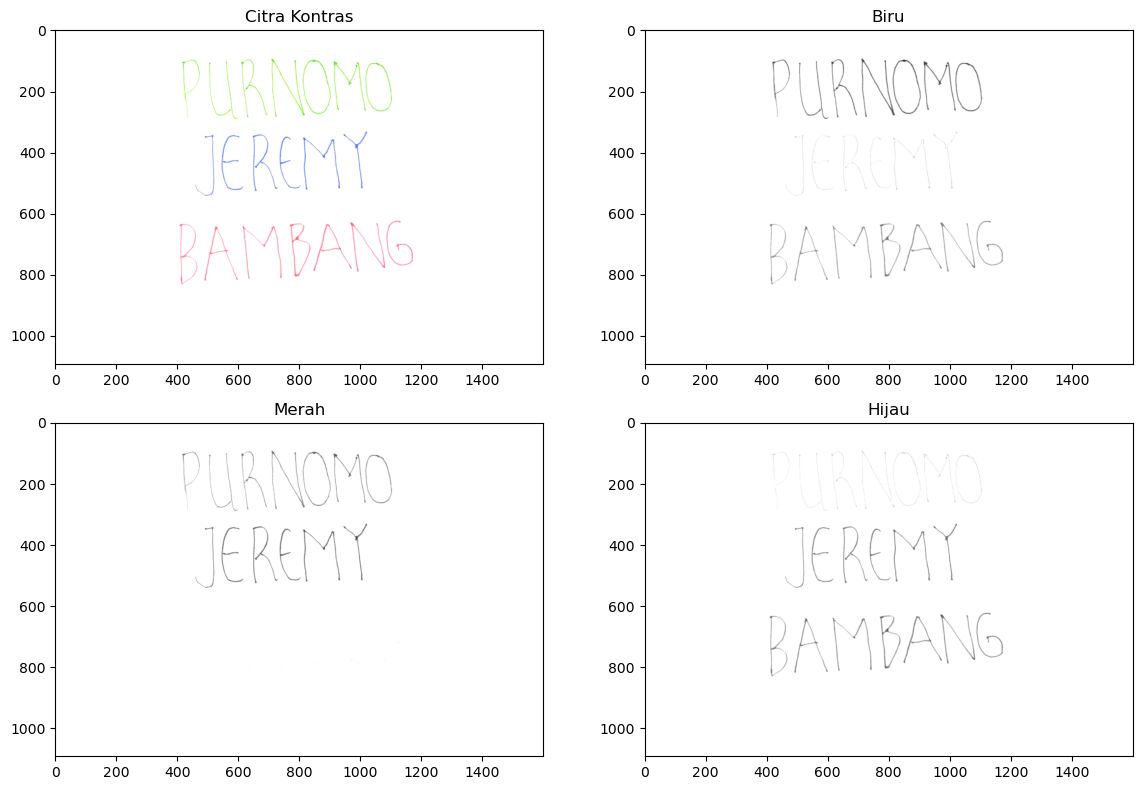

True

In [7]:
# 202431026_Purnomo Jeremy Bambang
# 1. BAGIAN D
# Memisahkan Kanal Warna Merah, Hijau, dan Biru

R = citra_kontras[:, :, 0]
G = citra_kontras[:, :, 1]
B = citra_kontras[:, :, 2]

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(citra_kontras)
plt.title('Citra Kontras')
plt.axis('on')

plt.subplot(2, 2, 2)
plt.imshow(B, cmap='gray', vmin=0, vmax=255)
plt.title('Biru')
plt.axis('on')

plt.subplot(2, 2, 3)
plt.imshow(R, cmap='gray', vmin=0, vmax=255)
plt.title('Merah')
plt.axis('on')

plt.subplot(2, 2, 4)
plt.imshow(G, cmap='gray', vmin=0, vmax=255)
plt.title('Hijau')
plt.axis('on')

plt.tight_layout()

# Menyimpan tampilan gabungan
plt.savefig('1. D. Output_Kanal_Warna.jpeg', dpi=300, bbox_inches='tight')

plt.show()

# Menyimpan hasil kanal warna satu per satu
cv2.imwrite('1. D. Kanal_Merah.jpeg', R)
cv2.imwrite('1. D. Kanal_Hijau.jpeg', G)
cv2.imwrite('1. D. Kanal_Biru.jpeg', B)

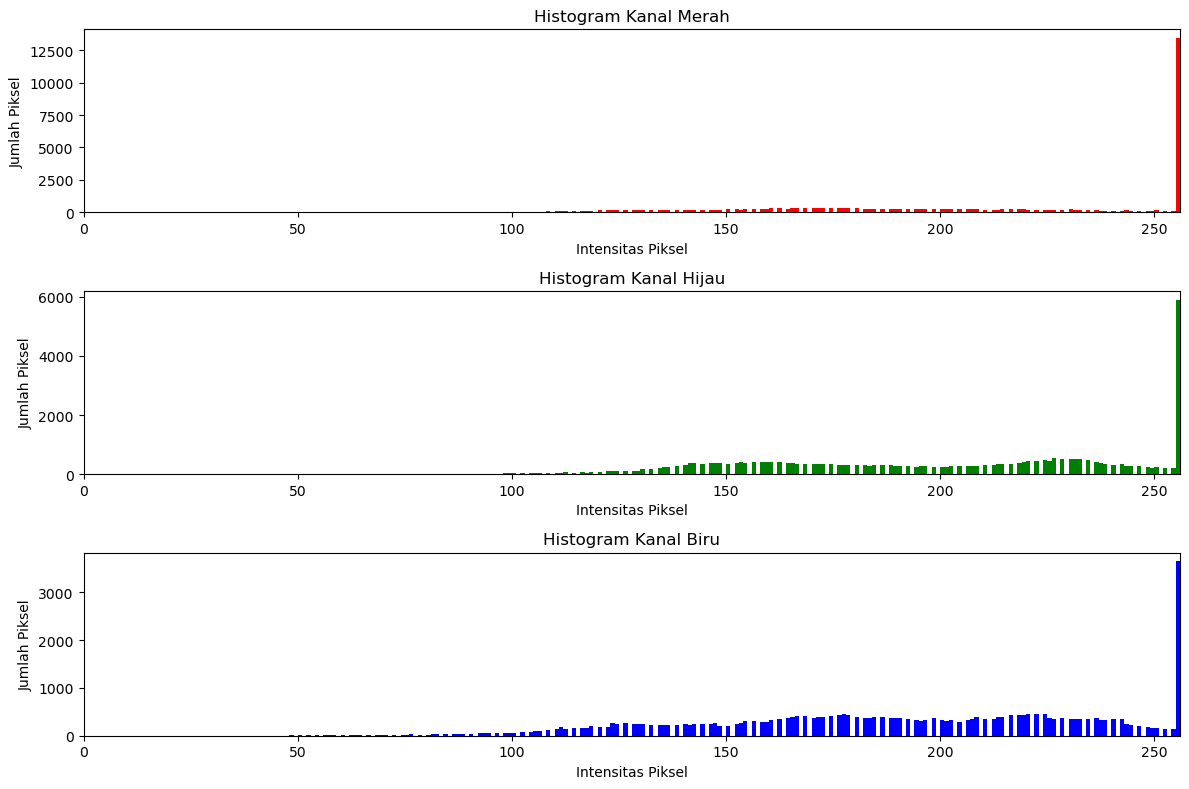

In [8]:
# 202431026_Purnomo Jeremy Bambang
# 1. BAGIAN C
# Histogram Tiap Kanal Warna

R_int = R.astype(np.int16)
G_int = G.astype(np.int16)
B_int = B.astype(np.int16)

# Menghitung rata-rata RGB
rata = (R_int + G_int + B_int) / 3

# Mengambil area yang bukan background putih
mask_tulisan = rata < 245

R_tulisan = R[mask_tulisan]
G_tulisan = G[mask_tulisan]
B_tulisan = B[mask_tulisan]

plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.hist(R_tulisan.ravel(), bins=256, range=[0, 256], color='red')
plt.title('Histogram Kanal Merah')
plt.xlabel('Intensitas Piksel')
plt.ylabel('Jumlah Piksel')
plt.xlim([0, 256])

plt.subplot(3, 1, 2)
plt.hist(G_tulisan.ravel(), bins=256, range=[0, 256], color='green')
plt.title('Histogram Kanal Hijau')
plt.xlabel('Intensitas Piksel')
plt.ylabel('Jumlah Piksel')
plt.xlim([0, 256])

plt.subplot(3, 1, 3)
plt.hist(B_tulisan.ravel(), bins=256, range=[0, 256], color='blue')
plt.title('Histogram Kanal Biru')
plt.xlabel('Intensitas Piksel')
plt.ylabel('Jumlah Piksel')
plt.xlim([0, 256])

plt.tight_layout()

# Menyimpan hasil histogram
plt.savefig('1. C. Histogram_Kanal_Warna.jpeg', dpi=300, bbox_inches='tight')

plt.show()

In [9]:
# 202431026_Purnomo Jeremy Bambang
# 1. BAGIAN E
# Menentukan Ambang Batas Warna

R_int = R.astype(np.int16)
G_int = G.astype(np.int16)
B_int = B.astype(np.int16)

# rata-rata piksel
rata = (R_int + G_int + B_int) / 3

# selisih nilai kanal terbesar dan terkecil
maks = np.maximum(np.maximum(R_int, G_int), B_int)
mins = np.minimum(np.minimum(R_int, G_int), B_int)
selisih = maks - mins

# Mask warna
# Background putih dibuang dengan syarat:
# rata < 245 dan selisih > 25

mask_biru = (B_int - R_int > 25) & (B_int - G_int > 20) & (rata < 245) & (selisih > 25)
mask_merah = (R_int - G_int > 20) & (R_int - B_int > 20) & (rata < 245) & (selisih > 25)
mask_hijau = (G_int - R_int > 20) & (G_int - B_int > 20) & (rata < 245) & (selisih > 25)

# Ubah ke citra biner 0 dan 255
hasil_biru = np.zeros_like(B, dtype=np.uint8)
hasil_merah = np.zeros_like(R, dtype=np.uint8)
hasil_hijau = np.zeros_like(G, dtype=np.uint8)

hasil_biru[mask_biru] = 255
hasil_merah[mask_merah] = 255
hasil_hijau[mask_hijau] = 255

# Menebalkan sedikit agar tulisan lebih jelas
kernel = np.ones((3, 3), np.uint8)

hasil_biru = cv2.morphologyEx(hasil_biru, cv2.MORPH_CLOSE, kernel)
hasil_merah = cv2.morphologyEx(hasil_merah, cv2.MORPH_CLOSE, kernel)
hasil_hijau = cv2.morphologyEx(hasil_hijau, cv2.MORPH_CLOSE, kernel)

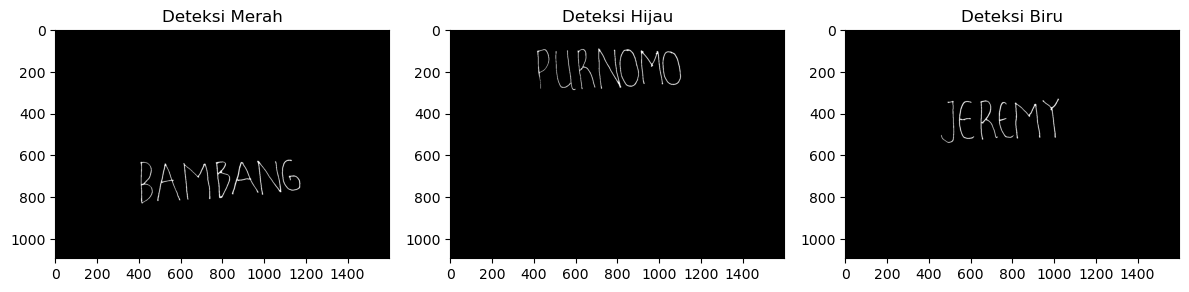

True

In [12]:
# 202431026_Purnomo Jeremy Bambang
# 1. BAGIAN A.3
# Menampilkan Hasil Deteksi Warna Merah, Hijau, dan Biru

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(hasil_merah, cmap='gray', vmin=0, vmax=255)
plt.title('Deteksi Merah')
plt.axis('on')

plt.subplot(1, 3, 2)
plt.imshow(hasil_hijau, cmap='gray', vmin=0, vmax=255)
plt.title('Deteksi Hijau')
plt.axis('on')

plt.subplot(1, 3, 3)
plt.imshow(hasil_biru, cmap='gray', vmin=0, vmax=255)
plt.title('Deteksi Biru')
plt.axis('on')

plt.tight_layout()

# Menyimpan tampilan gabungan deteksi warna
plt.savefig('1. A.3. Deteksi_Warna_RGB.jpeg', dpi=300, bbox_inches='tight')

plt.show()

# Menyimpan hasil deteksi masing-masing warna
cv2.imwrite('1. A.3. Deteksi_Merah.jpeg', hasil_merah)
cv2.imwrite('1. A.3. Deteksi_Hijau.jpeg', hasil_hijau)
cv2.imwrite('1. A.3. Deteksi_Biru.jpeg', hasil_biru)

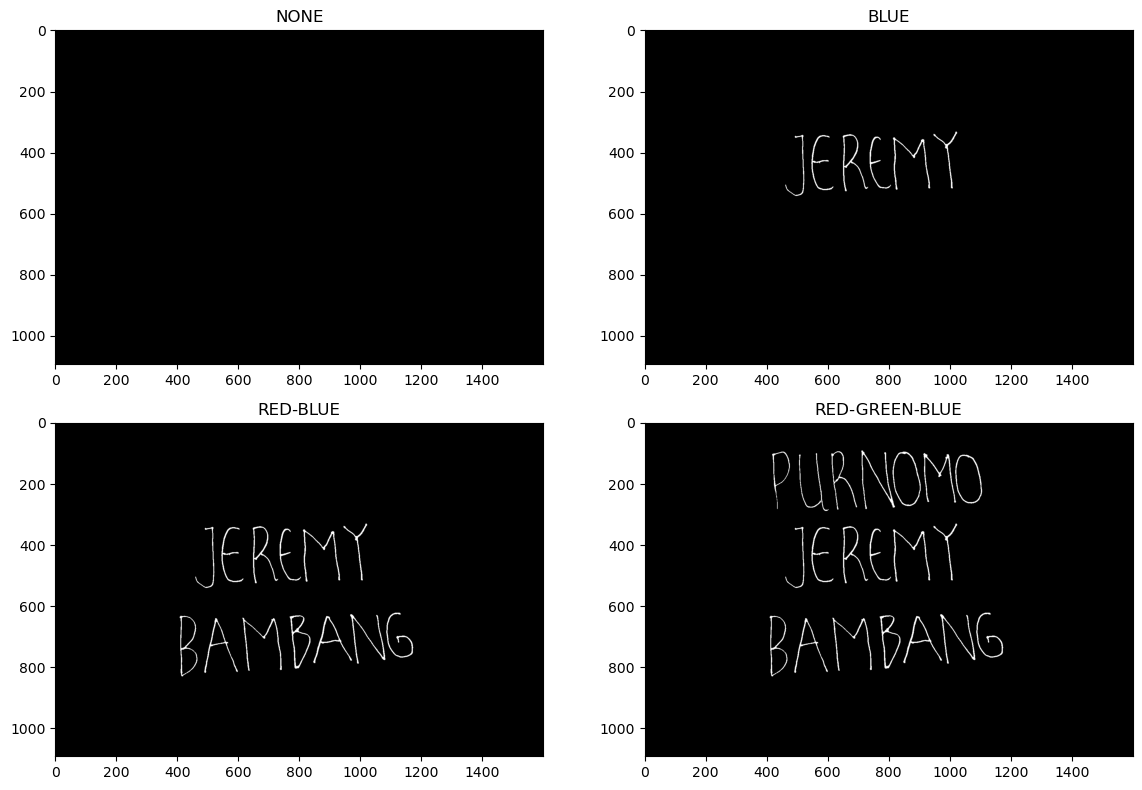

True

In [13]:
# 202431026_Purnomo Jeremy Bambang
# 1. BAGIAN F
# Menampilkan Hasil Ambang Batas Warna

# NONE = hitam semua
none = np.zeros_like(R, dtype=np.uint8)

# BLUE = hanya tulisan biru
blue_only = hasil_biru.copy()

# RED-BLUE = tulisan merah + biru
red_blue = cv2.bitwise_or(hasil_merah, hasil_biru)

# RED-GREEN-BLUE = semua warna
red_green_blue = cv2.bitwise_or(red_blue, hasil_hijau)

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(none, cmap='gray', vmin=0, vmax=255)
plt.title('NONE')
plt.axis('on')

plt.subplot(2, 2, 2)
plt.imshow(blue_only, cmap='gray', vmin=0, vmax=255)
plt.title('BLUE')
plt.axis('on')

plt.subplot(2, 2, 3)
plt.imshow(red_blue, cmap='gray', vmin=0, vmax=255)
plt.title('RED-BLUE')
plt.axis('on')

plt.subplot(2, 2, 4)
plt.imshow(red_green_blue, cmap='gray', vmin=0, vmax=255)
plt.title('RED-GREEN-BLUE')
plt.axis('on')

plt.tight_layout()

plt.savefig('1. F. Output_Kategori_Warna.jpeg', dpi=300, bbox_inches='tight')

plt.show()

cv2.imwrite('1. F. NONE.jpeg', none)
cv2.imwrite('1. F. BLUE.jpeg', blue_only)
cv2.imwrite('1. F. RED_BLUE.jpeg', red_blue)
cv2.imwrite('1. F. RED_GREEN_BLUE.jpeg', red_green_blue)